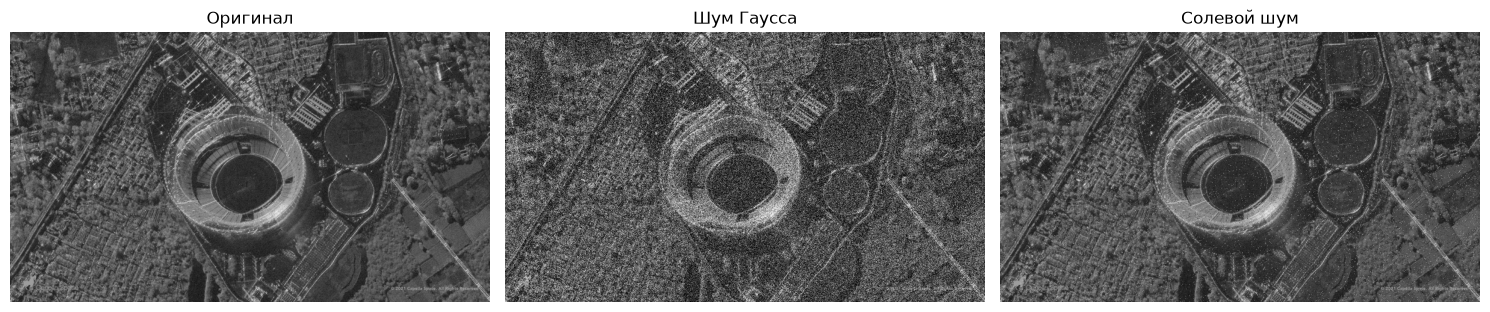

In [16]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy
from skimage.metrics import structural_similarity, mean_squared_error

image = cv2.imread('sar_1.jpg', cv2.IMREAD_GRAYSCALE)

#шум Гаусса
mean, stddev = 0, 70
noise_gauss = np.zeros(image.shape, np.float32)
cv2.randn(noise_gauss, mean, stddev)
image_gauss = np.clip(image.astype(np.float32) + noise_gauss, 0, 255).astype(np.uint8)

#солевой шум
noise = np.random.randint(0, 101, size=image.shape, dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel  = np.where(noise == 100)

image_sp = copy.deepcopy(image)
image_sp[zeros_pixel] = 0
image_sp[ones_pixel]  = 255

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image, cmap='gray');       ax[0].set_title('Оригинал')
ax[1].imshow(image_gauss, cmap='gray'); ax[1].set_title('Шум Гаусса')
ax[2].imshow(image_sp, cmap='gray');    ax[2].set_title('Солевой шум')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

In [17]:
def filter_test(noisy_image, clean_image):
    filters = [
        ('Гаусс 3x3', cv2.GaussianBlur(noisy_image, (3,3), 0)),
        ('Гаусс 5x5', cv2.GaussianBlur(noisy_image, (5,5), 0)),
        ('Гаусс 7x7', cv2.GaussianBlur(noisy_image, (7,7), 0)),
        ('Медиана 3x3', cv2.medianBlur(noisy_image, 3)),
        ('Медиана 5x5', cv2.medianBlur(noisy_image, 5)),
        ('Медиана 7x7', cv2.medianBlur(noisy_image, 7)),
        ('Билатер d=9 s=75', cv2.bilateralFilter(noisy_image, 9, 75, 75)),
        ('NLM h=15', cv2.fastNlMeansDenoising(noisy_image, None, 15)),
        ('NLM h=25', cv2.fastNlMeansDenoising(noisy_image, None, 25)),
    ]
    results = {}
    print(f"{'Фильтр':22s} {'MSE':>10s} {'SSIM':>9s}")
    print("-" * 45)
    for name, filtered in filters:
        mse = mean_squared_error(clean_image, filtered)
        ssim = structural_similarity(clean_image, filtered)
        print(f"{name:22s} {mse:10.2f} {ssim:9.4f}")
        results[name] = {'image': filtered, 'mse': mse, 'ssim': ssim}
    return results

In [18]:
print("Шум Гаусса")
res_gauss = filter_test(image_gauss, image)

print("\nСолевой шум")
res_sp = filter_test(image_sp, image)

Шум Гаусса
Фильтр                        MSE      SSIM
---------------------------------------------
Гаусс 3x3                  632.52    0.4001
Гаусс 5x5                  440.52    0.4614
Гаусс 7x7                  368.39    0.4848
Медиана 3x3                901.77    0.3178
Медиана 5x5                509.63    0.3728
Медиана 7x7                426.69    0.3744
Билатер d=9 s=75           970.61    0.2868
NLM h=15                  3677.99    0.1459
NLM h=25                  3639.44    0.1468

Солевой шум
Фильтр                        MSE      SSIM
---------------------------------------------
Гаусс 3x3                  122.26    0.7825
Гаусс 5x5                  143.08    0.7342
Гаусс 7x7                  182.81    0.6591
Медиана 3x3                 95.74    0.8163
Медиана 5x5                194.02    0.6332
Медиана 7x7                260.03    0.5224
Билатер d=9 s=75           267.01    0.5189
NLM h=15                   317.70    0.6260
NLM h=25                   232.66    0.5318


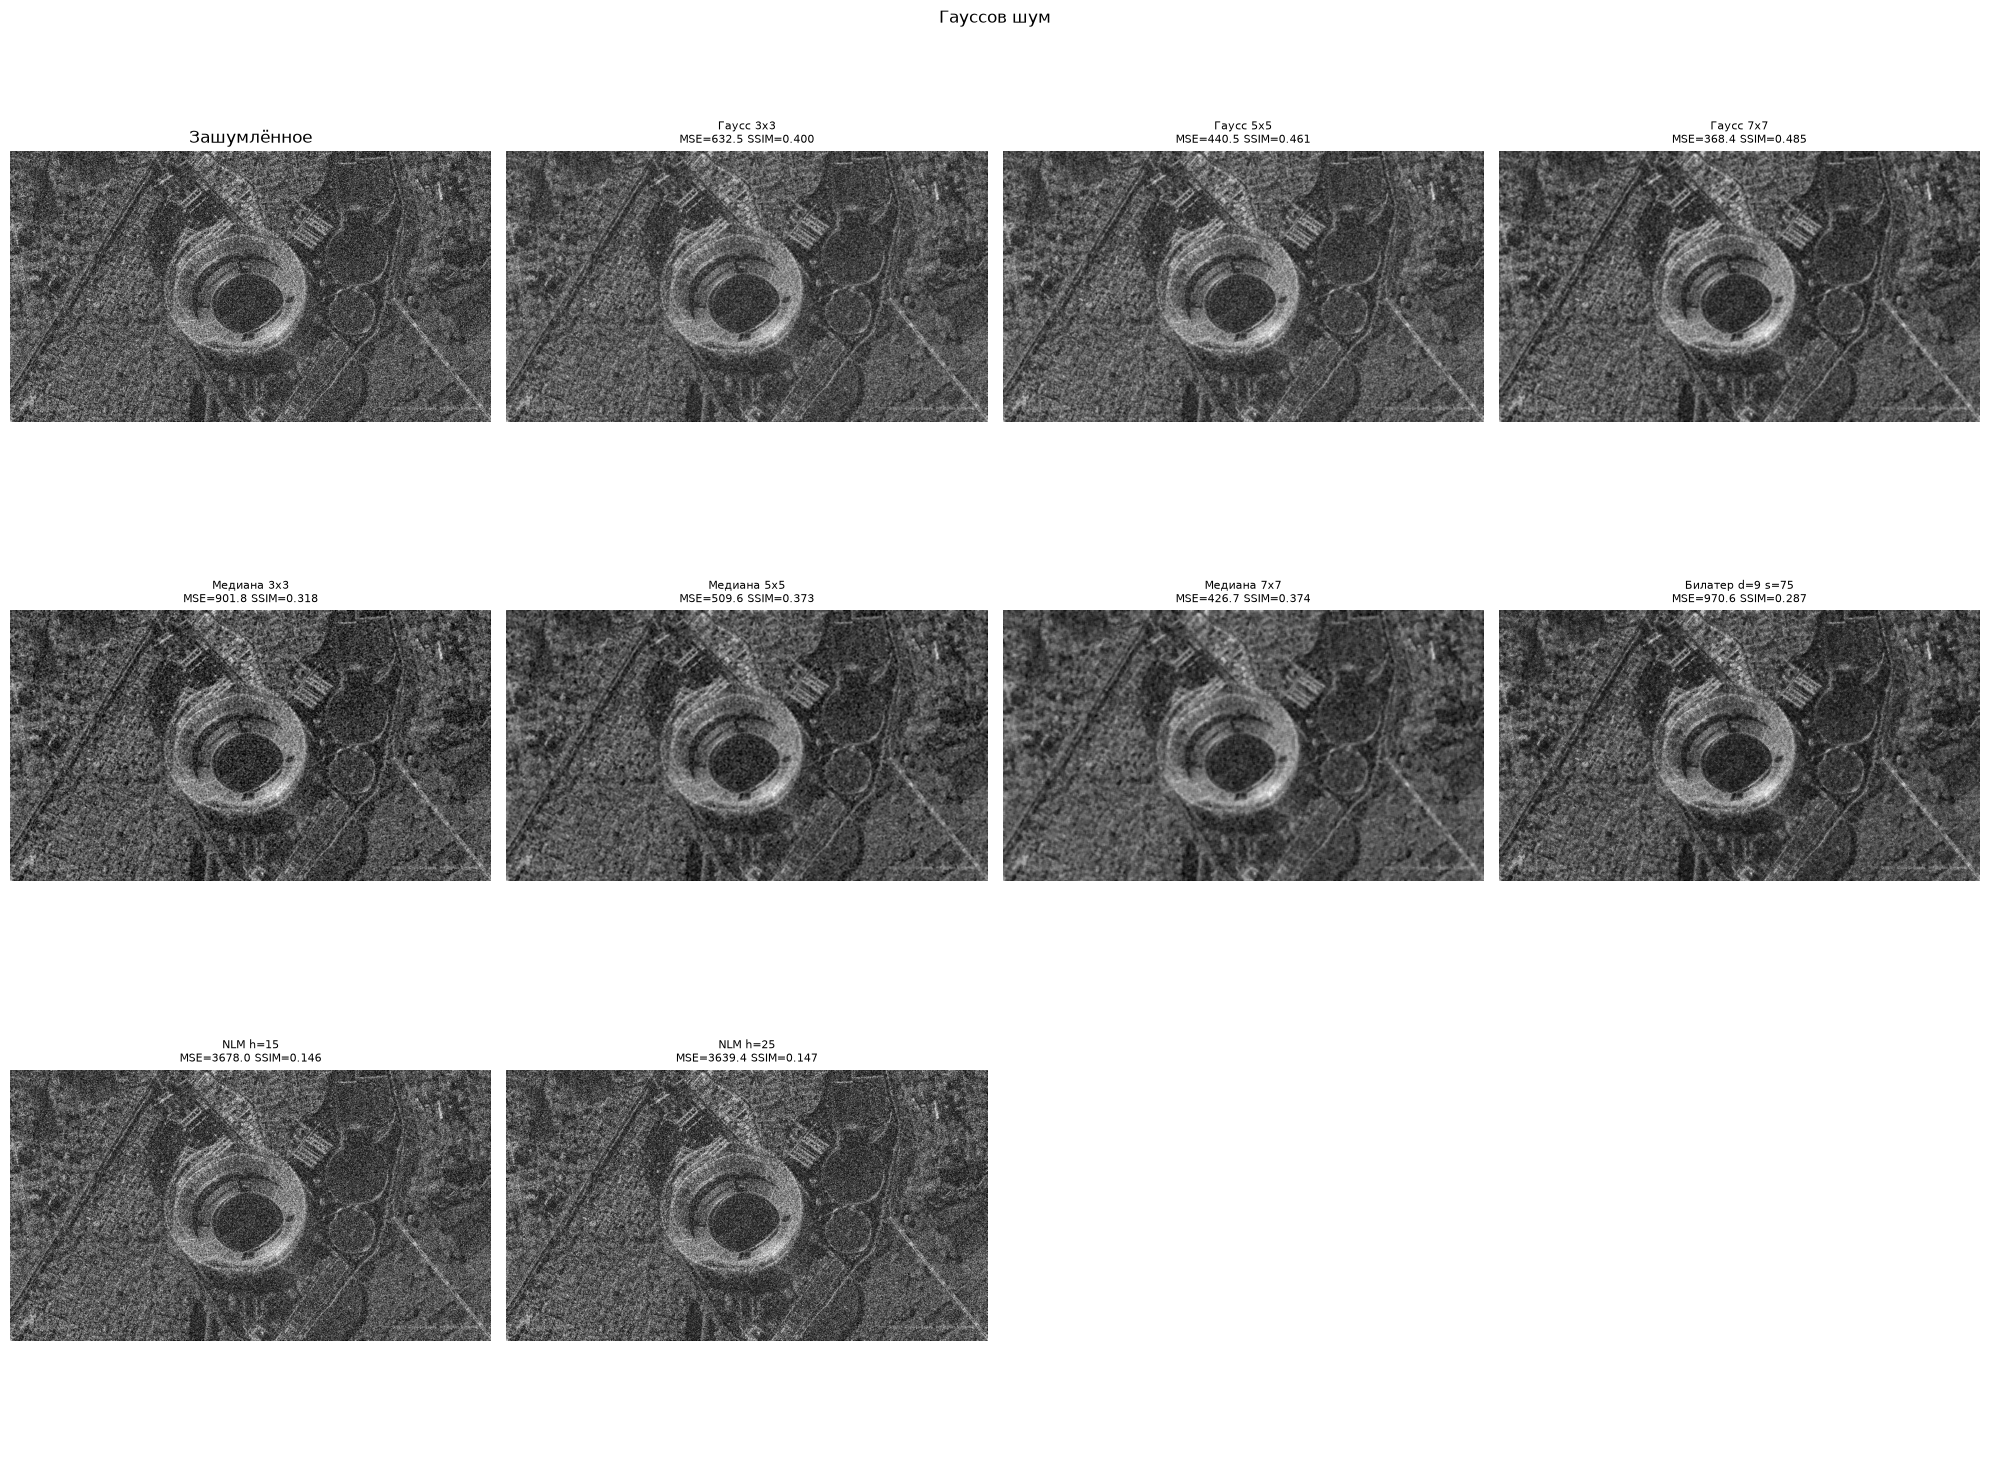

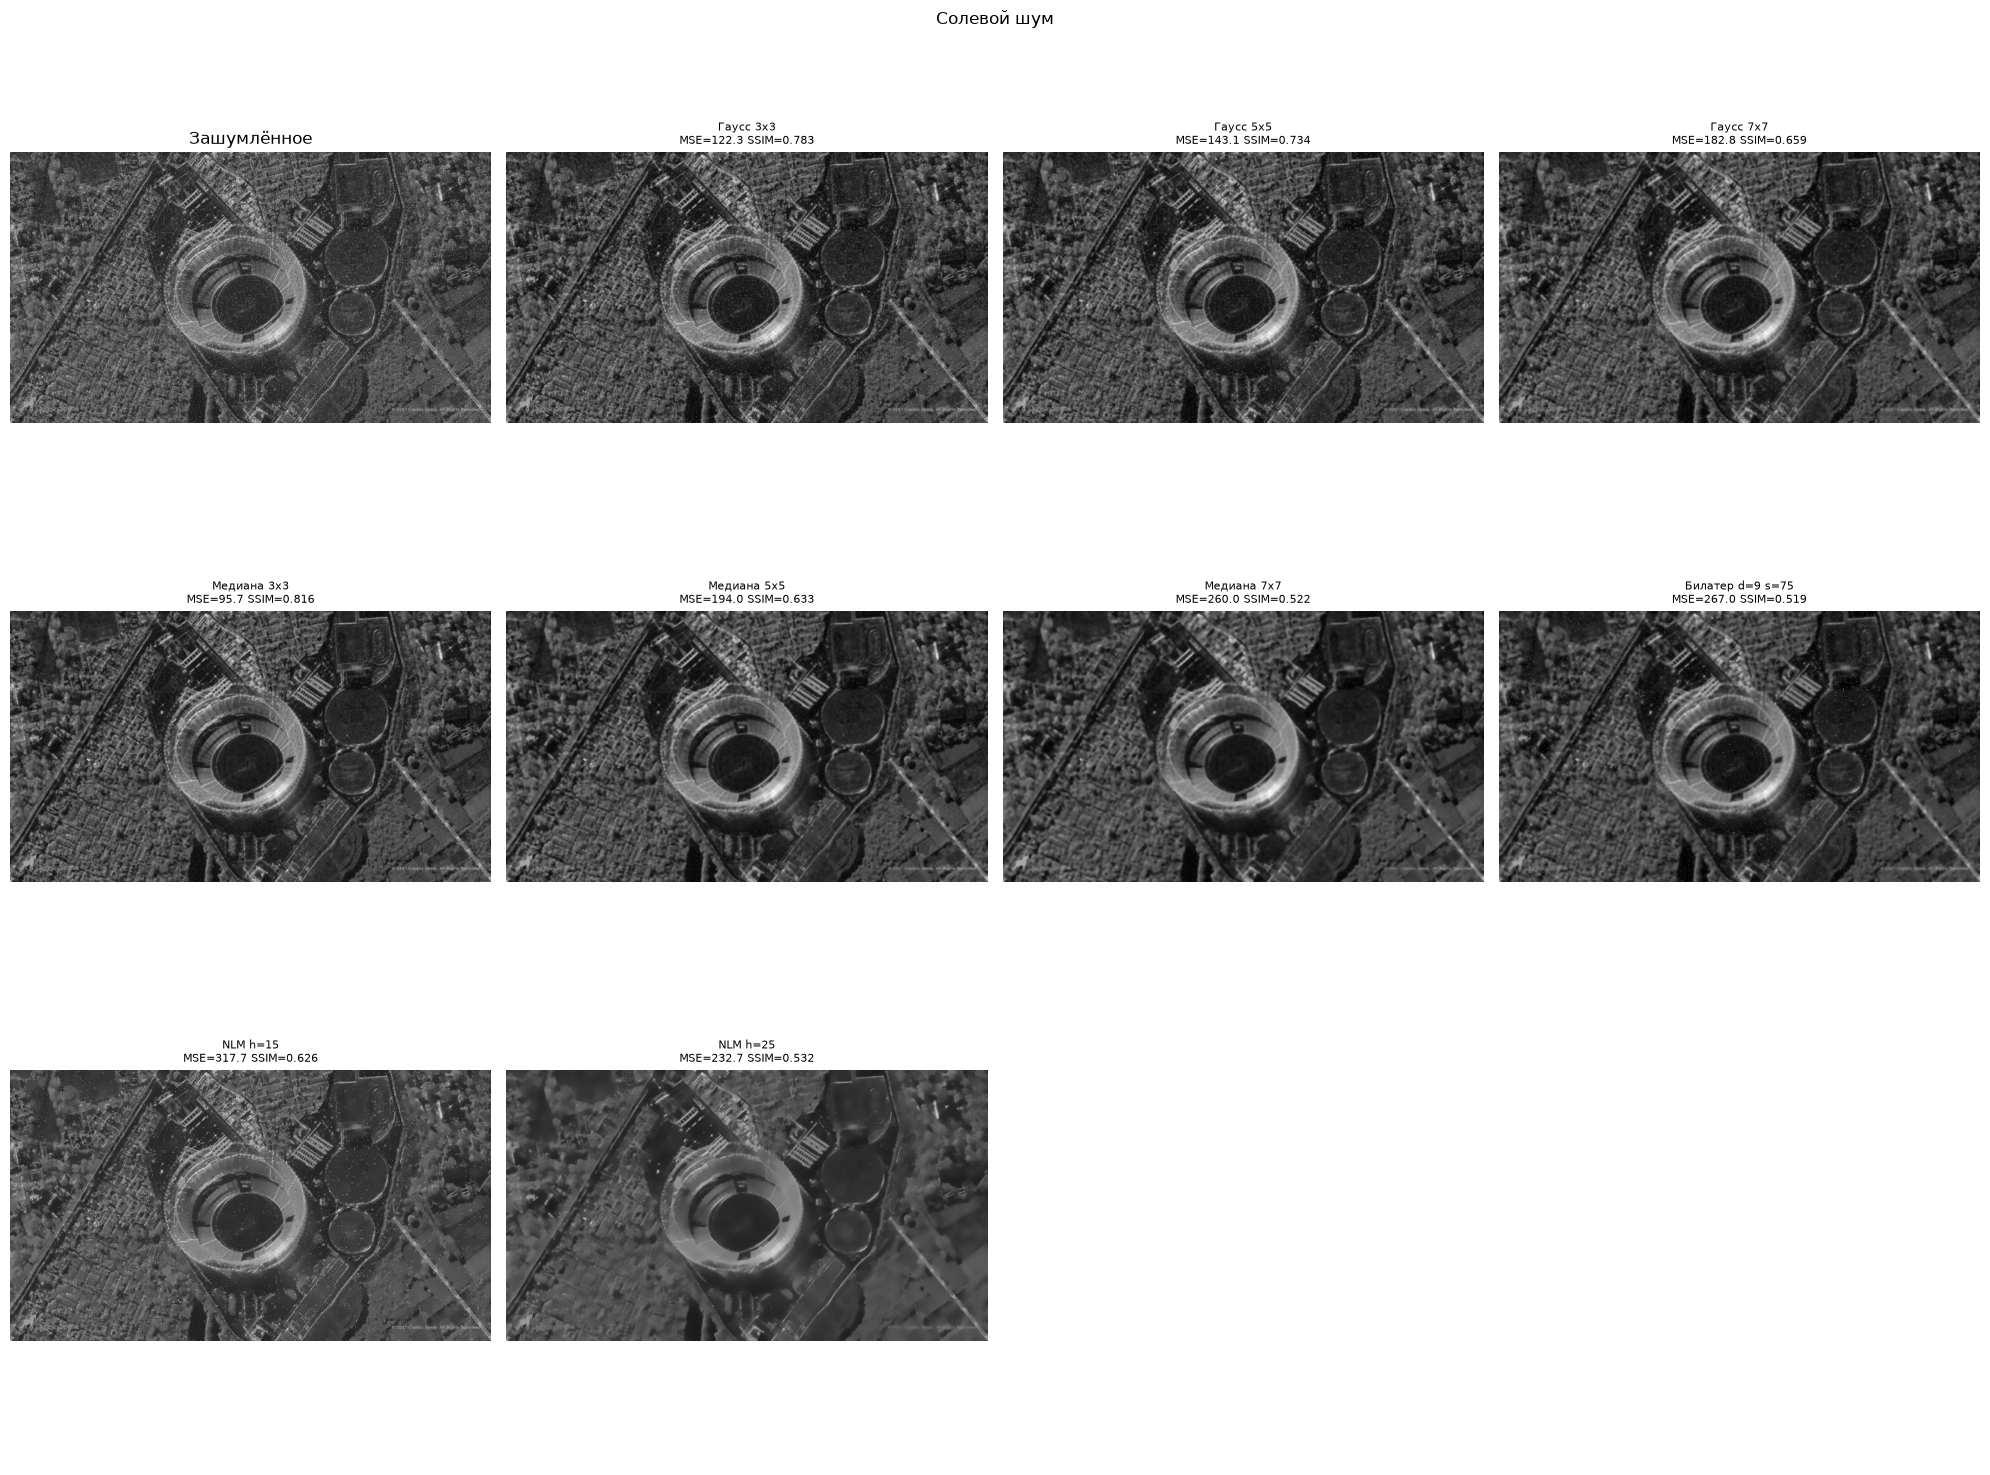

In [19]:
def visualize(noisy, results, title):
    n = len(results) + 1
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes = axes.flatten()
    axes[0].imshow(noisy, cmap='gray'); axes[0].set_title('Зашумлённое'); axes[0].axis('off')
    for i, (name, r) in enumerate(results.items(), 1):
        axes[i].imshow(r['image'], cmap='gray')
        axes[i].set_title(f"{name}\nMSE={r['mse']:.1f} SSIM={r['ssim']:.3f}", fontsize=8)
        axes[i].axis('off')
    for j in range(n, len(axes)): axes[j].axis('off')
    fig.suptitle(title); plt.tight_layout(); plt.show()

visualize(image_gauss, res_gauss, 'Гауссов шум')
visualize(image_sp, res_sp, 'Солевой шум')

In [20]:
bm = min(res_gauss.items(), key=lambda x: x[1]['mse'])
bs = max(res_gauss.items(), key=lambda x: x[1]['ssim'])
print("Шум Гаусса")
print("Лучший MSE :", bm[0], " MSE =", round(bm[1]['mse'], 2), " SSIM =", round(bm[1]['ssim'], 4))
print("Лучший SSIM:", bs[0], " MSE =", round(bs[1]['mse'], 2), " SSIM =", round(bs[1]['ssim'], 4))
print()

bm = min(res_sp.items(), key=lambda x: x[1]['mse'])
bs = max(res_sp.items(), key=lambda x: x[1]['ssim'])
print("Солевой шум")
print("Лучший MSE :", bm[0], " MSE =", round(bm[1]['mse'], 2), " SSIM =", round(bm[1]['ssim'], 4))
print("Лучший SSIM:", bs[0], " MSE =", round(bs[1]['mse'], 2), " SSIM =", round(bs[1]['ssim'], 4))

Шум Гаусса
Лучший MSE : Гаусс 7x7  MSE = 368.39  SSIM = 0.4848
Лучший SSIM: Гаусс 7x7  MSE = 368.39  SSIM = 0.4848

Солевой шум
Лучший MSE : Медиана 3x3  MSE = 95.74  SSIM = 0.8163
Лучший SSIM: Медиана 3x3  MSE = 95.74  SSIM = 0.8163
